In [1]:

import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt

import utils
import exp_models

In [2]:
# Reproducibility
SEED = 2019

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [3]:
transform = torchvision.transforms.transforms.Compose([
    torchvision.transforms.transforms.ToTensor()
])
trainset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='/data/landelle/datasets', train=False, download=True, transform=transform)
#trainset, testset


Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 100
N_BATCHES_IN_TRAIN_SET = len(trainset) // BATCH_SIZE
N_BATCHES_IN_TEST_SET = len(testset) // BATCH_SIZE
NUM_WORKERS = 8

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)


Traceback (most recent call last):
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/util.py", line 265, in _run_finalizers
    finalizer()
  File "/data/landelle/anaconda3/lib/python3.7/multiprocessing/util.py", line 189, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/data/landelle/anaconda3/lib/python3.7/shutil.py", line 495, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/data/landelle/anaconda3/lib/python3.7/shutil.py", line 493, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-vf_luj_i'


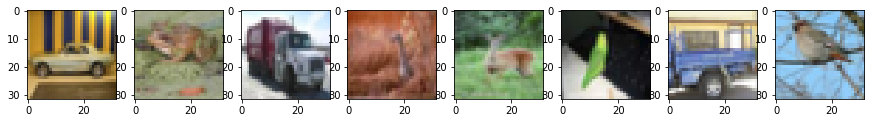

In [6]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for images, labels in trainloader:
    for i in range(8):
        utils.show_np_arr(images[i], ax=axes[i])
        #axes[i].set_title(trainset.classes[labels[i]])
    break
    

In [10]:

USE_CUDA = True
N_EPOCHS = 1
N_BATCHES = 1
LR = 0.001

model_getter = exp_models.resnet18

def perform_experiment(lambdas):
    print("saving results in", RESULTS_FNAME)
    print_ = utils.get_print(True, fname=RESULTS_FNAME)
    test_accs = {}
    train_losses = {str(k):[] for k in lambdas}
    val_losses = {str(k):[] for k in lambdas}
    for lambda_ in lambdas:
        print_("Trying lambda=", lambda_)        

        device = torch.device('cuda' if USE_CUDA else 'cpu')
        model = model_getter().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = torch.nn.CrossEntropyLoss()
        
        lam_rs = lambda_.reshape((-1, 1, 1, 1, 1))
        lam_rs_tensor = torch.from_numpy(lam_rs).float().to(device)

        NMIX = lam_rs_tensor.shape[0]
        print_("Performing n-mixup with N-mix:", NMIX)

        # Train mode
        model.train()
        for epoch in range(1, N_EPOCHS + 1):
            # Training on all batches
            print_("Epoch[{}/{}]".format(epoch, N_EPOCHS))
            for batch_id, (images, labels) in enumerate(trainloader):
                if N_BATCHES and batch_id > N_BATCHES:
                    break
                labels, images = labels.to(device), images.to(device)
                images_mx, ys, perms = utils.mixup_data_nmix(NMIX, images, labels, lam_rs_tensor, device)
                outputs = model(images_mx)
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_losses[str(lambda_)].append(loss_value)
                if batch_id % 50 == 0:
                    print_('train loss:{:.4f} Epoch[{}/{}] Batch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS, batch_id, N_BATCHES_IN_TRAIN_SET))
                    
            # Validating on one batch
            for images, labels in testloader:
                correct = 0
                total = 0
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                val_acc = 100 * correct / total
                loss = utils.mixup_criterion_nmix(criterion, outputs, ys, lam_rs_tensor)
                loss_value = loss.item()

                print_('val loss:{:.4f} Epoch[{}/{}]'.format(
                        loss_value, epoch, N_EPOCHS))
                print_('val acc:{:.4f} Epoch[{}/{}]'.format(
                        val_acc, epoch, N_EPOCHS))
                val_losses[str(lambda_)].append(loss_value)
                break

        # Test mode
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in testloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                predicted = torch.argmax(outputs, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            # Output test accuracy
            test_acc = 100 * correct / total
            print_('Test Accuracy of the model on the test images: {} %'.format(test_acc))
            test_accs[str(lambda_)] = test_acc


        del device, model, optimizer, criterion
    return test_accs, train_losses, val_losses, images_mx, ys


In [22]:

LAMBDAS = [np.array([1-l/8, l/8]) for l in range(5)][2:3]
LAMBDAS

[array([0.75, 0.25])]

In [23]:

for n in range(2):
    RESULTS_FNAME = "r_cf10_rn18_n2_grid_DELETE"+str(n)
    with open("results/"+RESULTS_FNAME, "w"):pass
    test_accs, train_losses, val_losses, images_mx, ys = perform_experiment(LAMBDAS)
    print(RESULTS_FNAME, LAMBDAS)


saving results in r_cf10_rn18_n2_grid_DELETE0
Trying lambda= [0.75 0.25]
Performing n-mixup with N-mix: 2
Epoch[1/1]
train loss:2.4265 Epoch[1/1] Batch[0/500]
val loss:3.1808 Epoch[1/1]
val acc:11.0000 Epoch[1/1]
Test Accuracy of the model on the test images: 10.0 %
r_cf10_rn18_n2_grid_DELETE0 [array([0.75, 0.25])]
saving results in r_cf10_rn18_n2_grid_DELETE1
Trying lambda= [0.75 0.25]
Performing n-mixup with N-mix: 2
Epoch[1/1]
train loss:2.3204 Epoch[1/1] Batch[0/500]
val loss:2.6555 Epoch[1/1]
val acc:13.0000 Epoch[1/1]
Test Accuracy of the model on the test images: 10.0 %
r_cf10_rn18_n2_grid_DELETE1 [array([0.75, 0.25])]


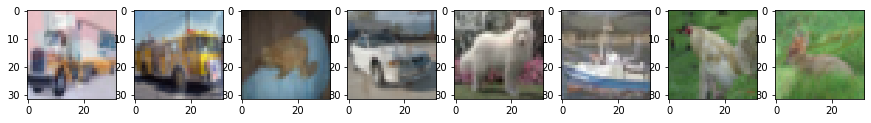

In [24]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i in range(8):
    utils.show_np_arr(images_mx[i].cpu(), ax=axes[i])
    #axes[i].set_title(trainset.classes[ys[0][i]]+" + "+trainset.classes[ys[1][i]], fontsize=10)
    pass

Text(0.5, 0.98, 'N=5 sweetspot Fixed mixup samples')

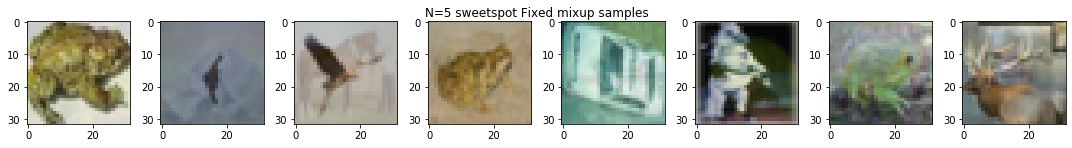

In [53]:
fig, axes = plt.subplots(1, 8, figsize=(15, 2))
for i, x in enumerate(images_mx[40:48]):
    utils.show_np_arr(x.cpu(), ax=axes[i])
fig.tight_layout()
fig.suptitle("N=5 sweetspot Fixed mixup samples")